<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W03_BMKG_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-3 Assignment: data_bmkg_2.xls
___
Name: Arief Purnama Muharram<br>
Student number: 23521013

In [ ]:
# Install all of the requirements.
!pip install pandas
!pip install numpy
!pip install scikit-learn 
!pip install imbalanced-learn

In [ ]:
# Upgrade the xlrd package to read xls file.
!pip install xlrd>=1.2.0
!pip install --upgrade xlrd

In [ ]:
# Connect the Google Colab with the Google Drive account
# so the Colab can access the Drive's contents.
from google.colab import drive 
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Set Pandas options.
pd.set_option('display.max_columns', None)

# Import the data.
# I place the data in the Google Drive's root folder.
df = pd.read_excel('/content/drive/MyDrive/data_bmkg_2.xls')

# Print sample of the data.
print('[data_bmkg_2.xls]')
print(df.head(5))

print('\n')

# Print summary of the data.
print('[Data Summary]')
print(df.info())

[data_bmkg_2.xls]
  id_station               name_station      nama_kota nama_propinsi  \
0    STA2172  AWS Maritim Tanjung Priok  Jakarta Utara   DKI Jakarta   
1    STA2172  AWS Maritim Tanjung Priok  Jakarta Utara   DKI Jakarta   
2    STA2172  AWS Maritim Tanjung Priok  Jakarta Utara   DKI Jakarta   
3    STA2172  AWS Maritim Tanjung Priok  Jakarta Utara   DKI Jakarta   
4    STA2172  AWS Maritim Tanjung Priok  Jakarta Utara   DKI Jakarta   

          lat        lon      data_timestamp   rr  wd_avg  ws_avg  ws_max  \
0  '-6.100232  '106.8771 2021-03-01 00:01:00  0.0   243.0     0.0     NaN   
1  '-6.100232  '106.8771 2021-03-01 00:03:00  0.0   247.0     0.0     NaN   
2  '-6.100232  '106.8771 2021-03-01 00:04:00  0.0   241.0     0.0     NaN   
3  '-6.100232  '106.8771 2021-03-01 00:05:00  0.0   242.0     0.0     NaN   
4  '-6.100232  '106.8771 2021-03-01 00:06:00  0.0   234.0     0.0     NaN   

   tt_air_min  tt_air_avg  tt_air_max  rh_avg  pp_air  sr_avg  sr_max  
0        28.4 

## Data preprocessing
___

In [ ]:
# [Understanding the problem]
# The aim of this task is to identify whether the weather is normal or extreme.
# An extreme weather is determined by the following characteristics.
# - Air temperature: < 15 or > 35 degree Celcius
# - Rain rate: > 100 mm/day
# - Air humidity: < 40%
# - Wind speed: > 10,7 m/s

In [ ]:
# [Drop the unnecessary data attribute]
# In this case, we don't need all except data attribute that can distinguish
# between normal and extreme weather.

df = df.drop(['id_station', 'name_station', 'nama_kota', 'nama_propinsi', 
              'lat', 'lon', 'data_timestamp'], 
             axis=1, inplace=False)

# Print the data info.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20462 entries, 0 to 20461
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rr          20337 non-null  float64
 1   wd_avg      20337 non-null  float64
 2   ws_avg      20337 non-null  float64
 3   ws_max      11468 non-null  float64
 4   tt_air_min  20337 non-null  float64
 5   tt_air_avg  20337 non-null  float64
 6   tt_air_max  11468 non-null  float64
 7   rh_avg      20337 non-null  float64
 8   pp_air      20337 non-null  float64
 9   sr_avg      20337 non-null  float64
 10  sr_max      20337 non-null  float64
dtypes: float64(11)
memory usage: 1.7 MB
None


In [ ]:
# [Clean the null data]
# If there is row containing any null data, clean it!

df = df.dropna(how='any', inplace=False)

# Print the data info.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11468 entries, 8984 to 20461
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rr          11468 non-null  float64
 1   wd_avg      11468 non-null  float64
 2   ws_avg      11468 non-null  float64
 3   ws_max      11468 non-null  float64
 4   tt_air_min  11468 non-null  float64
 5   tt_air_avg  11468 non-null  float64
 6   tt_air_max  11468 non-null  float64
 7   rh_avg      11468 non-null  float64
 8   pp_air      11468 non-null  float64
 9   sr_avg      11468 non-null  float64
 10  sr_max      11468 non-null  float64
dtypes: float64(11)
memory usage: 1.0 MB
None


In [ ]:
# [Is there any duplicated data?]
# Check the possibility of duplicate data on all rows.

total_duplicated_data = df.duplicated(keep='first').sum()

# Print the result.
print('There are ' + str(total_duplicated_data) + ' duplicated rows in the data!')

There are 183 duplicated rows in the data!


In [ ]:
# [Drop the duplicate data]

df.drop_duplicates(keep='first', inplace=True)

# Print the data info.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11285 entries, 8984 to 20461
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rr          11285 non-null  float64
 1   wd_avg      11285 non-null  float64
 2   ws_avg      11285 non-null  float64
 3   ws_max      11285 non-null  float64
 4   tt_air_min  11285 non-null  float64
 5   tt_air_avg  11285 non-null  float64
 6   tt_air_max  11285 non-null  float64
 7   rh_avg      11285 non-null  float64
 8   pp_air      11285 non-null  float64
 9   sr_avg      11285 non-null  float64
 10  sr_max      11285 non-null  float64
dtypes: float64(11)
memory usage: 1.0 MB
None


In [ ]:
# [Is the weather normal or extreme?]
# Determine whether the weather normal or extreme based on the determined
# criteria.

import numpy as np

df['conclusion'] = np.where((df['tt_air_avg'] < 15) | (df['tt_air_avg'] > 35) | (df['rr'] > 100) | (df['rh_avg'] < 40.0) | (df['ws_avg'] > 10.7), 'E', 'N')

print(df.groupby(['conclusion']).size())

conclusion
E      633
N    10652
dtype: int64


## Statistical Description
___

In [ ]:
# [Generate descriptive statistics of the data]

df.describe()

,rr,wd_avg,ws_avg,ws_max,tt_air_min,tt_air_avg,tt_air_max,rh_avg,pp_air,sr_avg,sr_max
count,11285.000000,11285.000000,11285.000000,11285.000000,11285.000000,11285.000000,11285.000000,11285.000000,1.128500e+04,11285.000000,11285.000000
mean,2.298715,150.382314,153.361779,137.701442,27.299739,27.380032,27.487097,83.781805,7.298007e+04,169.384797,182.270200
std,5.521731,183.515568,647.941896,760.872868,2.373445,2.382063,2.387825,11.785351,2.588257e+05,330.707937,347.293749
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,25.400000,25.400000,25.500000,73.700000,1.009200e+03,0.000000,0.000000
50%,0.200000,122.000000,0.500000,1.000000,26.800000,26.900000,26.900000,85.600000,1.010500e+03,0.000000,0.000000
75%,2.400000,296.000000,1.700000,2.400000,29.490000,29.500000,29.600000,94.400000,1.011400e+03,216.800000,239.100000
max,41.600000,7687.000000,5284.000000,7925.000000,34.310000,34.800000,35.190000,100.000000,1.006097e+06,7686.000000,5765.000000


## Artificial Neural Network (ANN)
___

### Imbalance Dataset Approach
____

In [ ]:
# [Create train and test dataset]

from sklearn.model_selection import train_test_split

X = df.drop(['conclusion'], axis=1, inplace=False)
y = df['conclusion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [ ]:
# [Multi-layer perceptron model]

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    solver='adam', alpha=1e-5, hidden_layer_sizes=(5,2), random_state=1
)

mlp.fit(X_train, y_train)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), random_state=1)

[Confusion Matrix]



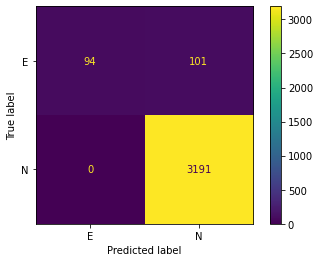

In [ ]:
# [Confusion matrix]

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=mlp.classes_)
disp.plot()

# Print the info
print("[Confusion Matrix]\n")
plt.show()

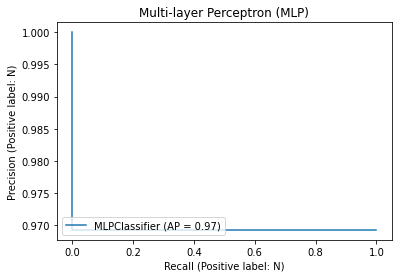

In [ ]:
# [Precision and recall]

from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    mlp, X_test, y_test
)

_ = display.ax_.set_title("Multi-layer Perceptron (MLP)")

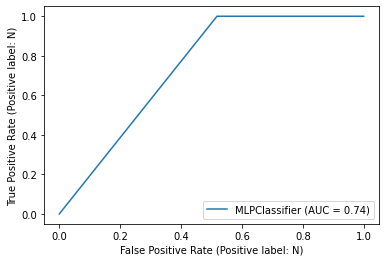

In [ ]:
# [ROC and AUC]

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(mlp, X_test, y_test)

### Balance Dataset Approach:
### Undersampling
___

In [ ]:
# [Balancing the data]

from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

X = df.drop(['conclusion'], axis=1, inplace=False)
y = df['conclusion']

rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X, y)

print(sorted(Counter(y_resampled).items()))

[('E', 633), ('N', 633)]


In [ ]:
# [Create train and test data]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=0
)

In [ ]:
# [Multi-layer perceptron model]

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    solver='adam', alpha=1e-5, hidden_layer_sizes=(5,2), random_state=1
)

mlp.fit(X_train, y_train)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), random_state=1)

[Confusion Matrix]



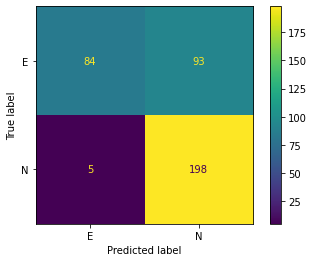

In [ ]:
# [Confusion matrix]

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=mlp.classes_)
disp.plot()

# Print the info
print("[Confusion Matrix]\n")
plt.show()

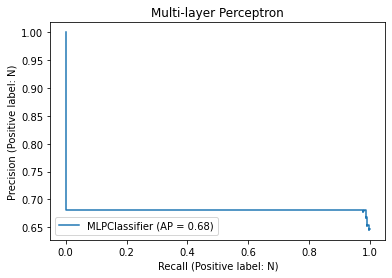

In [ ]:
# [Precision and recall]

from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    mlp, X_test, y_test
)

_ = display.ax_.set_title("Multi-layer Perceptron")

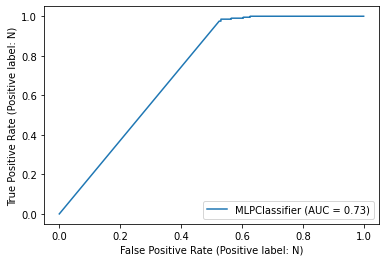

In [ ]:
# [ROC and AUC]

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    mlp, X_test, y_test
)